Probleme de classif diabte ou pas

In [ ]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.feature_selection import f_classif # ANOVA F-test 
from sklearn.feature_selection import mutual_info_classif # Mutual Information
import xgboost as xgb # XGboost
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.svm import SVC # SVM

# ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import random

# XAI
from lime.lime_tabular import LimeTabularExplainer
import shap

In [2]:
%pwd

'c:\\Users\\Amal\\Desktop\\Predict Diabetes\\Predict_Diabetes\\notebook'

In [3]:
%cd ..

c:\Users\Amal\Desktop\Predict Diabetes\Predict_Diabetes


C:\Users\Amal\AppData\Roaming\Python\Python39\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [7]:
# Dézipper le fichier
with zipfile.ZipFile("dataset/Diabetes_Dataset.zip", "r") as z:
    print(z.namelist())  # liste les fichiers contenus dans le zip
    z.extractall("dataset/Diabetes_Dataset_unzipped")  # extrait tout dans un dossier

['diabetes_dataset.csv']


In [4]:
# Lire le CSV 
df = pd.read_csv("dataset/Diabetes_Dataset_unzipped/diabetes_dataset.csv")
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
target = "Outcome"  

Dataset Columns:

 - Pregnancies (Integer): Number of times the patient has been pregnant.
 - Glucose (Integer): Plasma glucose concentration after a 2-hour oral glucose tolerance test.
 - BloodPressure (Integer): Diastolic blood pressure (mm Hg).
 - SkinThickness (Integer): Triceps skinfold thickness (mm).
 - Insulin (Integer): 2-hour serum insulin (mu U/ml).
 - BMI (Float): Body mass index (weight in kg/(height in m)^2).
 - DiabetesPedigreeFunction (Float): A function that represents the patient’s diabetes pedigree (i.e., likelihood of diabetes based on family history).
 - Age (Integer): Age of the patient (years).
 - Outcome (Binary/int): Binary outcome (0 or 1) where 1 indicates the presence of diabetes and 0 indicates the absence.

# 1. EDA

In [5]:
# 2. Aperçu général
print("lignes, colonnes:", df.shape)
print(df.info())

lignes, colonnes: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [6]:
# 3. Valeurs manquantes
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


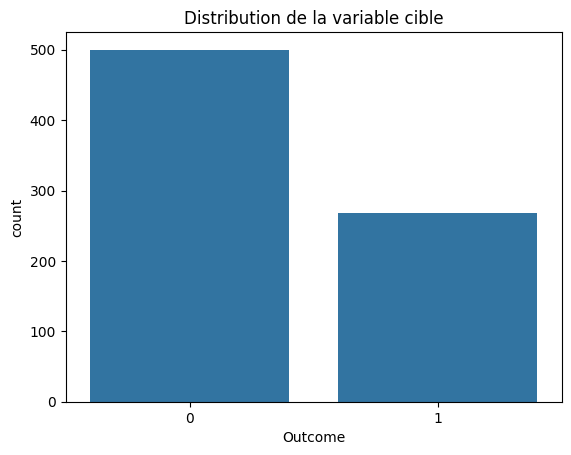

In [ ]:
# 5. Distribution de la variable cible 
sns.countplot(x=target, data=df)
plt.title("Distribution de la variable cible")
plt.show()

In [104]:
num_cols = df.select_dtypes(include="number").columns

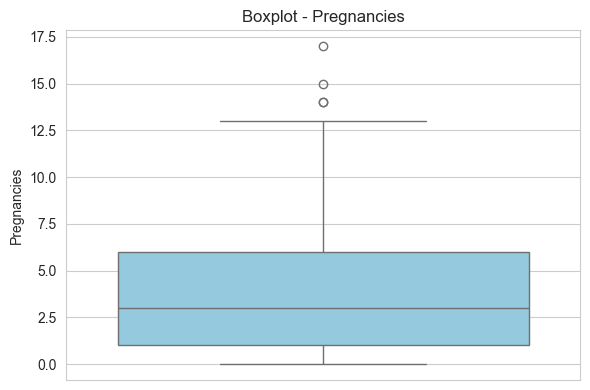

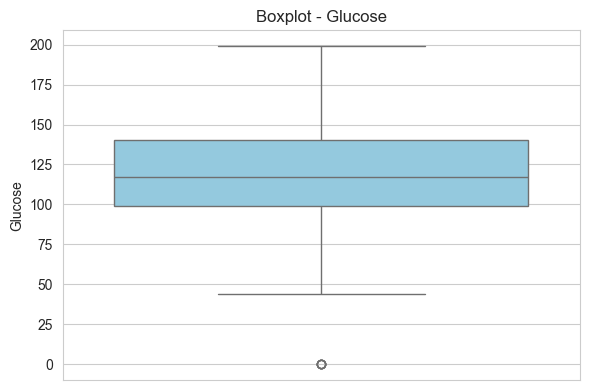

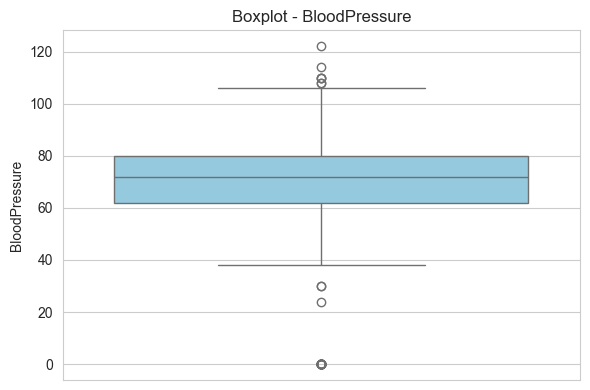

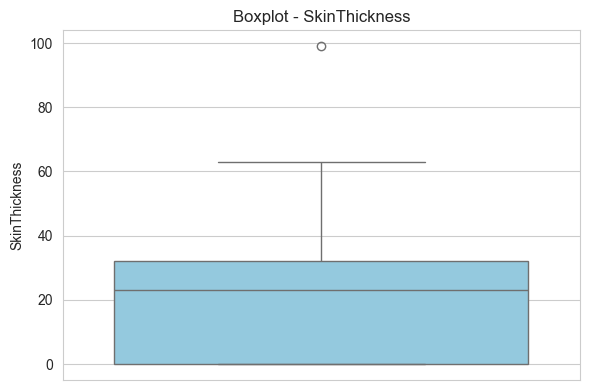

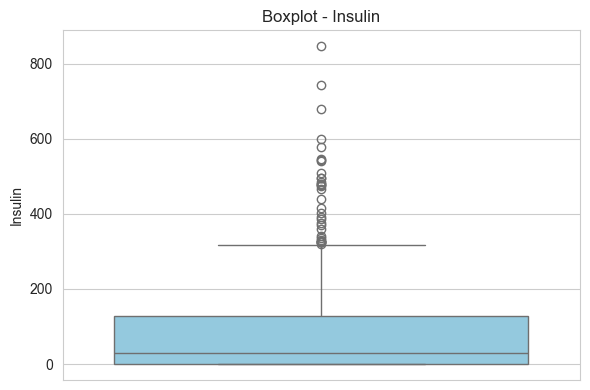

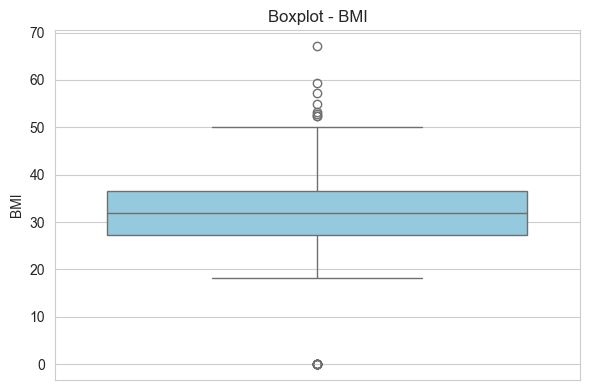

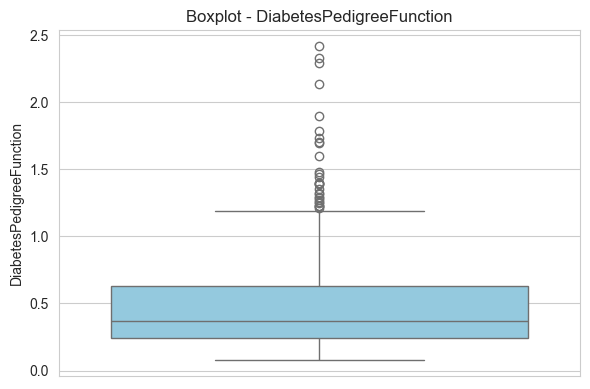

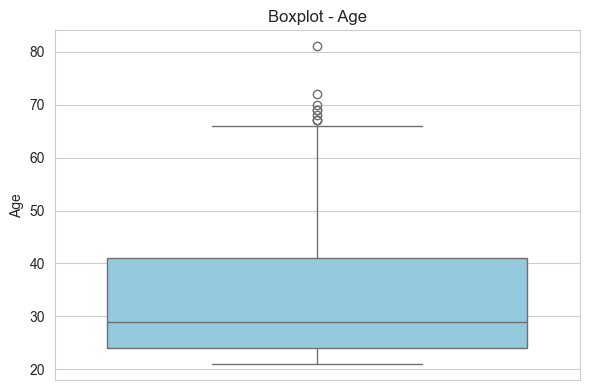

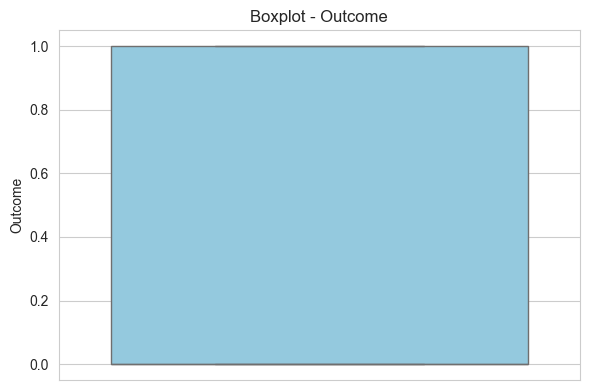

In [6]:
# 7. Boxplots pour détecter les outliers

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y = df[col], color="skyblue")
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [10]:
def get_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers

for col in num_cols:
    outliers = get_outliers_iqr(df, col)
    print(f"Nombre d'outliers: {len(outliers)}")
    if len(outliers) > 0:
        print("Index df",outliers[[col]].sort_values(col).to_string())

Nombre d'outliers: 4
Index df      Pregnancies
298           14
455           14
88            15
159           17
Nombre d'outliers: 5
Index df      Glucose
75         0
182        0
342        0
349        0
502        0
Nombre d'outliers: 45
Index df      BloodPressure
7                0
703              0
426              0
430              0
435              0
453              0
468              0
484              0
494              0
522              0
533              0
535              0
589              0
601              0
604              0
619              0
643              0
697              0
347              0
336              0
357              0
300              0
15               0
49               0
60               0
78               0
81               0
332              0
172              0
706              0
193              0
222              0
261              0
266              0
269              0
597             24
125             30
18              30
362  

In [113]:
def plotHistogram(values, label, feature, title):
    sns.set_style("whitegrid")
    plotOne = sns.FacetGrid(values, hue=label, aspect=2)
    plotOne.map(sns.histplot, feature)
    plotOne.set(xlim=(0, values[feature].max()))
    plotOne.add_legend()
    plotOne.set_axis_labels(feature, 'Proportion')
    plotOne.fig.suptitle(title)
    plt.show()

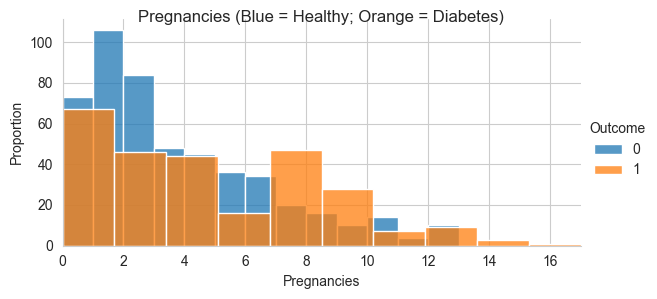

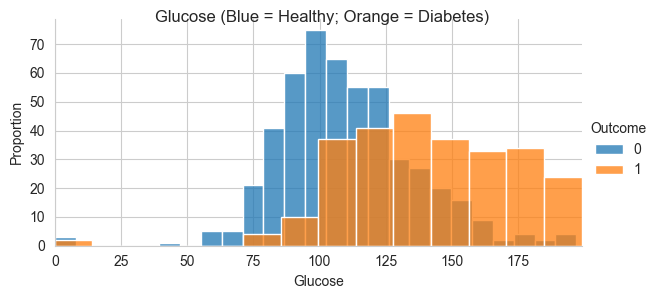

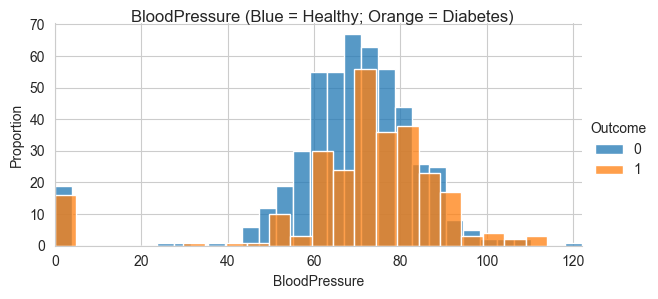

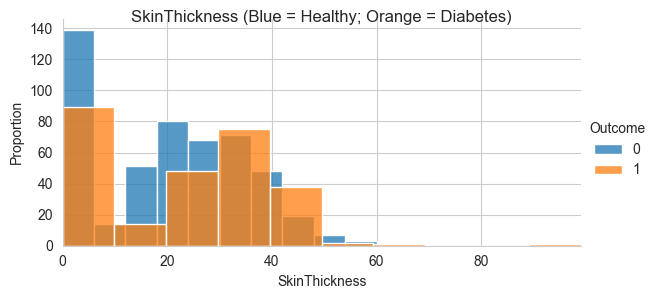

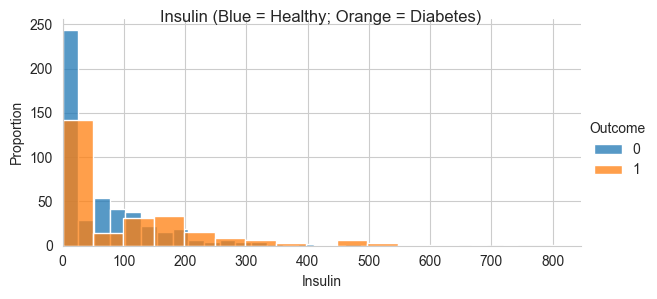

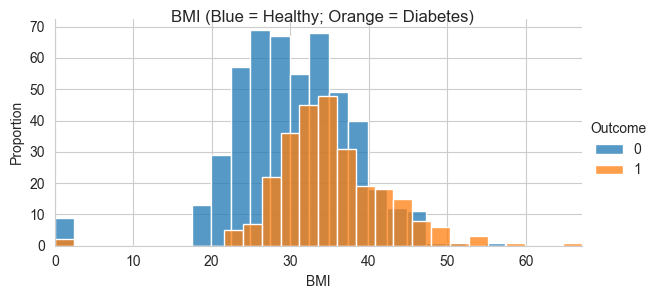

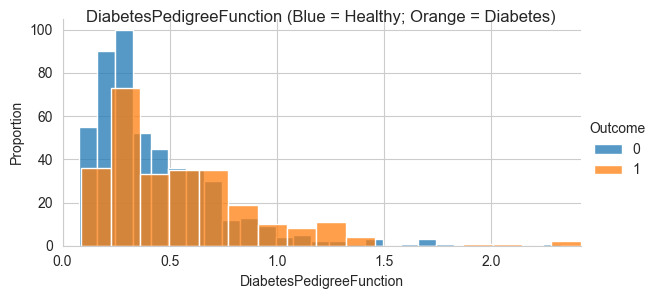

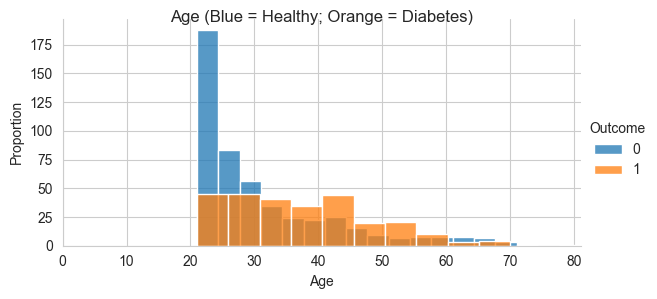

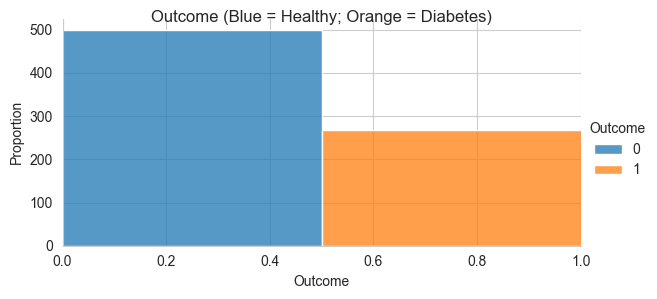

In [114]:
for col in num_cols:
    plotHistogram(df , target, col, f'{col} (Blue = Healthy; Orange = Diabetes)')

# 2. Feature selection

1. Méthodes de filtre (Filter methods)

Elles évaluent chaque feature indépendamment du modèle, avec des tests statistiques. MI, Anova et correlation

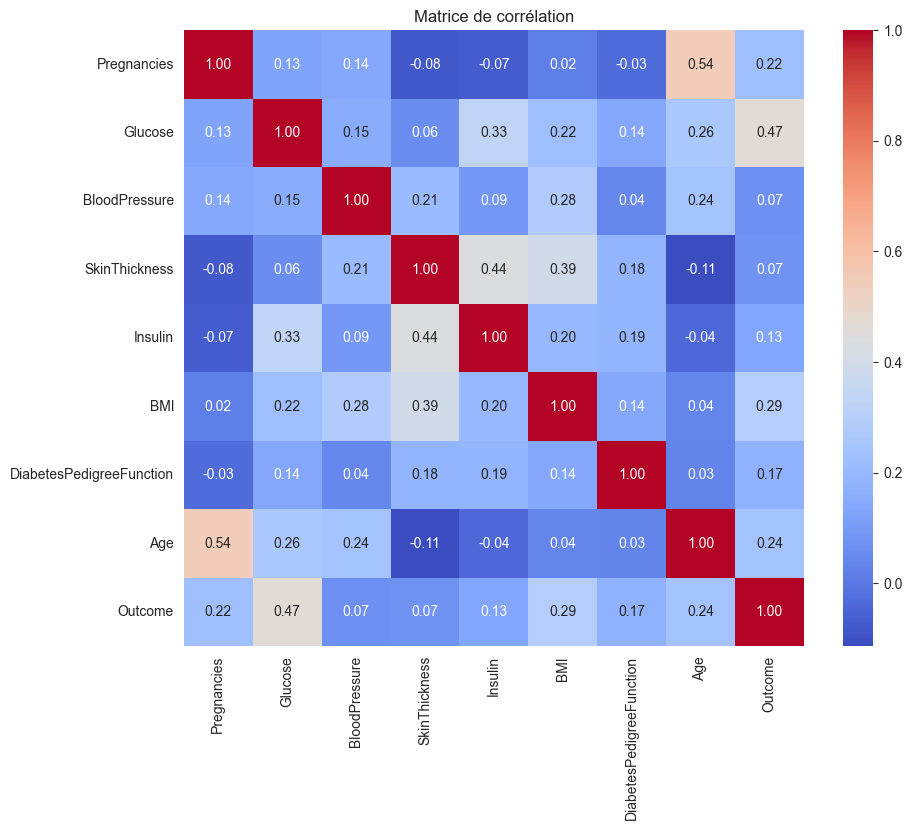

Corrélation de chaque feature avec la target

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [71]:
# 1. Matrice de corrélation
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

# Corrélation de chaque feature avec la target
print("Corrélation de chaque feature avec la target" + "\n")
print(corr["Outcome"].sort_values(ascending=False))

In [ ]:
# 2. ANOVA F-test 

# Calculer les scores F et p-values
f_scores, p_values = f_classif(X, y)

# Afficher les résultats
for i, col in enumerate(X.columns):
    print(f"{col}: F-score = {f_scores[i]:.4f}, p-value = {p_values[i]:.4f}")
    
# Si p < 0.05 → Différence significative (on rejette H₀)
# Si p ≥ 0.05 → Différence non significative (on garde H₀)

#UNE VARIABLE EST IMPORTANTE SI :
# p-value < 0.05 (significative)
# F-score élevé (grande variance entre groupes)

Pregnancies: F-score = 39.6702, p-value = 0.0000
Glucose: F-score = 213.1618, p-value = 0.0000
BloodPressure: F-score = 3.2570, p-value = 0.0715
SkinThickness: F-score = 4.3044, p-value = 0.0383
Insulin: F-score = 13.2811, p-value = 0.0003
BMI: F-score = 71.7721, p-value = 0.0000
DiabetesPedigreeFunction: F-score = 23.8713, p-value = 0.0000
Age: F-score = 46.1406, p-value = 0.0000


In [102]:
# Trier par F-Score (du plus grand au plus petit)
results = np.argsort(f_scores)[::-1]

# Afficher
for i in results:
    print(f"{X.columns[i]}: F-score = {f_scores[i]:.4f}")

Glucose: F-score = 213.1618
BMI: F-score = 71.7721
Age: F-score = 46.1406
Pregnancies: F-score = 39.6702
DiabetesPedigreeFunction: F-score = 23.8713
Insulin: F-score = 13.2811
SkinThickness: F-score = 4.3044
BloodPressure: F-score = 3.2570


In [ ]:
# 3. Mutual Information

# Calculate MI for aLL columns
mi_scores = mutual_info_classif (X, y)

# Sort descending (highest to lowest)
sorted_indices = np.argsort(mi_scores)[::-1]  # descending order
for i in sorted_indices:
    print(f"{X.columns[i]}: MI = {mi_scores[i]:.4f}")

Glucose: MI = 0.1165
BMI: MI = 0.0761
Age: MI = 0.0668
Insulin: MI = 0.0498
BloodPressure: MI = 0.0342
SkinThickness: MI = 0.0194
DiabetesPedigreeFunction: MI = 0.0142
Pregnancies: MI = 0.0015


 2.  Méthodes embarquées (Embedded methods)

La sélection se fait pendant l'entraînement du modèle — souvent avec des modèles à base d'arbres ou de régularisation.

Feature importance avec Random Forest / XGBoost (le plus utilisé en pratique, vu qu'on en a parlé plus haut) :


In [ ]:
# 1. Random Forest

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# rf.feature_importances_ : donne un score pour chaque feature, indiquant à quel point
# elle a été utile pour réduire l'impureté (Gini) dans les splits, moyenné sur les 200 arbres.
# La SOMME de tous les scores = 1.

Glucose                     0.255198
BMI                         0.167063
Age                         0.136674
DiabetesPedigreeFunction    0.123510
BloodPressure               0.090281
Pregnancies                 0.084964
Insulin                     0.075432
SkinThickness               0.066878
dtype: float64


In [ ]:
# 2. XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, random_state=42)
xgb_model.fit(X, y)
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

Glucose                     0.255511
BMI                         0.148983
Age                         0.137409
DiabetesPedigreeFunction    0.101409
BloodPressure               0.097171
SkinThickness               0.095227
Pregnancies                 0.084984
Insulin                     0.079306
dtype: float32


# 3. Training

In [242]:
def chercher_false_positives_ou_negatives_predection (y_pred, y_test):

# y_test doit être un array aligné avec X_test_scaled
 y_test_arr = np.array(y_test).flatten()

# Séparer les 2 types d'erreurs (utile pour une RCA plus fine)
 false_positives_idx = np.where((y_pred == 1) & (y_test_arr == 0))[0]  # prédit diabétique, mais non
 false_negatives_idx = np.where((y_pred == 0) & (y_test_arr == 1))[0]  # prédit non-diabétique, mais l'est

 print(f"Faux positifs (prédit diabétique, mais non) : {len(false_positives_idx)}")
 print(f"Faux négatifs (prédit non-diabétique, mais l'est) : {len(false_negatives_idx)}")

In [9]:
def calculate_errors(y_pred, y_test):

 errors = np.abs(y_pred - y_test.values)
 n_errors = (errors == 1).sum()

 print(f"Nombre d'erreurs: {n_errors} / {len(y_test)}")
 print(f"Taux d'erreur: {n_errors / len(y_test):.2%}")

1. Split data

In [243]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test, 80% pour l'entraînement
    random_state=42     
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (614, 8), Test: (154, 8)


2. Training

2.1 XGBoost 

In [ ]:
def XGBoost (X_train, X_test) :
    
    xgb_model = xgb.XGBClassifier(n_estimators = 200, random_state=42)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    calculate_errors(y_pred_xgb, y_test)
    
    # return y_pred_xgb

In [12]:
liste_feature_drop = ['Insulin', 'Pregnancies', "SkinThickness","BloodPressure","DiabetesPedigreeFunction"]

In [12]:
G=[]
for i in range(len(liste_feature_drop)):
    print("drop features", G)
    X_train_1 = X_train.drop(G, axis=1)
    X_test_1 = X_test.drop(G, axis=1)
    XGBoost (X_train_1, X_test_1)
    G.append(liste_feature_drop[i])

drop features []
Nombre d'erreurs: 45 / 154
Taux d'erreur: 29.22%
drop features ['Insulin']
Nombre d'erreurs: 45 / 154
Taux d'erreur: 29.22%
drop features ['Insulin', 'Pregnancies']
Nombre d'erreurs: 45 / 154
Taux d'erreur: 29.22%
drop features ['Insulin', 'Pregnancies', 'SkinThickness']
Nombre d'erreurs: 41 / 154
Taux d'erreur: 26.62%
drop features ['Insulin', 'Pregnancies', 'SkinThickness', 'BloodPressure']
Nombre d'erreurs: 42 / 154
Taux d'erreur: 27.27%


We drop 'Insulin', 'Pregnancies', 'SkinThickness features because Taux d'erreur moins for training SVM and ANN

In [244]:
X_train_1 = X_train.drop(['Insulin', 'Pregnancies', "SkinThickness"], axis=1)
X_test_1 = X_test.drop(['Insulin', 'Pregnancies', "SkinThickness"], axis=1)             

2.2 SVM

In [245]:
# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_1)
X_test_scaled = scaler.transform(X_test_1)  # transform seulement, pas fit, sur le test

svm_model = SVC(kernel="rbf", C=1, gamma=0.04, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm))

calculate_errors(y_pred_svm, y_test)
chercher_false_positives_ou_negatives_predection(y_pred_svm, y_test)

              precision    recall  f1-score   support

           0       0.82      0.85      0.83        99
           1       0.71      0.65      0.68        55

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.78      0.78      0.78       154

Nombre d'erreurs: 34 / 154
Taux d'erreur: 22.08%
Faux positifs (prédit diabétique, mais non) : 15
Faux négatifs (prédit non-diabétique, mais l'est) : 19


2.3 ANN 

In [251]:
# Split train data into train and validation sets
X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(
    X_train_1, y_train, test_size=0.10, random_state=42, stratify=y_train
)

print(f"Train: {X_train_2.shape}, Validation: {X_val_2.shape}, Test: {X_test_1.shape}")

Train: (552, 5), Validation: (62, 5), Test: (154, 5)


In [253]:
# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2)
X_val_scaled = scaler.transform(X_val_2)
X_test_scaled = scaler.transform(X_test_1) 

In [255]:
seed = 45
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# l2 pénalise les poids trop élevés
# Dropout empêche le réseau de trop dépendre d'un seul neurone/feature
# Construction du modèle (équivalent hidden_layer_sizes=(64,32))
model_ANN = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.1), input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.1)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # binaire ; softmax + n_classes si multi-classe
])

model_ANN.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',   # 'sparse_categorical_crossentropy' si multi-classe
    metrics=['accuracy']
)

# Early stopping natif, basé sur la val_loss
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True  # récupère automatiquement les meilleurs poids
)

# Reduce LR by factor of 10 when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,  # Divide by 10 (multiply by 0.1)
    patience=5,  # Wait 5 epochs before reducing
    min_lr=1e-7,  # Minimum learning rate
    verbose=1
)

# Entraînement
history = model_ANN.fit(
    X_train_scaled, y_train_2,
    validation_data=(X_val_scaled, y_val_2),  # jeu de validation externe, comme tu voulais
    epochs=100,
    batch_size=4,
    shuffle=True,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
138/138 [==============================] - 5s 8ms/step - loss: 0.9913 - accuracy: 0.6594 - val_loss: 0.6505 - val_accuracy: 0.7097 - lr: 0.0100
Epoch 2/100
138/138 [==============================] - 0s 3ms/step - loss: 0.6531 - accuracy: 0.7011 - val_loss: 0.6174 - val_accuracy: 0.7097 - lr: 0.0100
Epoch 3/100
138/138 [==============================] - 0s 3ms/step - loss: 0.6394 - accuracy: 0.6938 - val_loss: 0.6511 - val_accuracy: 0.7742 - lr: 0.0100
Epoch 4/100
138/138 [==============================] - 0s 3ms/step - loss: 0.6453 - accuracy: 0.7083 - val_loss: 0.6055 - val_accuracy: 0.7581 - lr: 0.0100
Epoch 5/100
138/138 [==============================] - 0s 3ms/step - loss: 0.6297 - accuracy: 0.7138 - val_loss: 0.5851 - val_accuracy: 0.7903 - lr: 0.0100
Epoch 6/100
138/138 [==============================] - 1s 5ms/step - loss: 0.6368 - accuracy: 0.7138 - val_loss: 0.6119 - val_accuracy: 0.6935 - lr: 0.0100
Epoch 7/100
138/138 [==============================] - 1s 6ms/st

In [256]:
#  Prédiction 
y_pred_prob = model_ANN.predict(X_test_scaled,verbose=0)

# Conversion avec seuil à 0.5 (standard)
y_pred_ANN = (y_pred_prob.flatten() > 0.5).astype(int)

# Evaluation
calculate_errors(y_pred_ANN, y_test)
chercher_false_positives_ou_negatives_predection(y_pred_ANN, y_test)
print("")
print(classification_report(y_test, y_pred_ANN))

Nombre d'erreurs: 32 / 154
Taux d'erreur: 20.78%
Faux positifs (prédit diabétique, mais non) : 11
Faux négatifs (prédit non-diabétique, mais l'est) : 21

              precision    recall  f1-score   support

           0       0.81      0.89      0.85        99
           1       0.76      0.62      0.68        55

    accuracy                           0.79       154
   macro avg       0.78      0.75      0.76       154
weighted avg       0.79      0.79      0.79       154



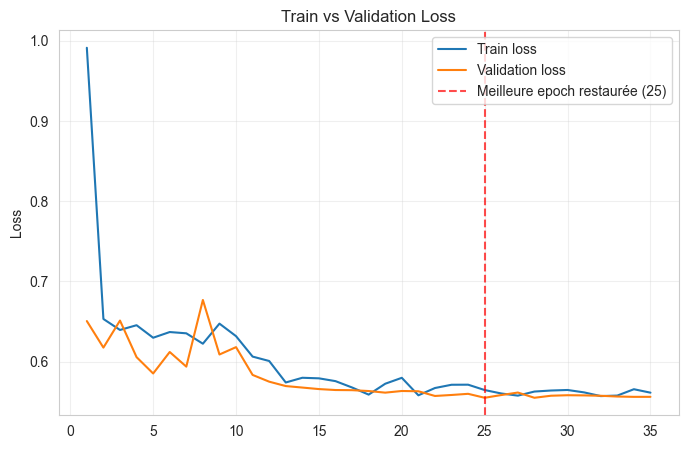

In [257]:
best_epoch = len(history.history['loss']) - early_stop.patience

epochs = range(1, len(history.history['loss']) + 1)

# --- Tracer loss train vs val ---
plt.figure(figsize=(8, 5))
plt.plot(epochs,history.history['loss'], label='Train loss')
plt.plot(epochs, history.history['val_loss'], label='Validation loss')
plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.7, 
            label=f'Meilleure epoch restaurée ({best_epoch})')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# XAI (eXplainable AI)

1. Méthodes intrinsèques (interprétables par construction)

Modèles simples dont la logique est directement lisible :

- Régression linéaire — coefficients directement interprétables
- Arbres de décision — règles de décision explicites

1. Méthodes post-hoc agnostiques

S'appliquent à n'importe quel modèle « boîte noire»

1.1. Locales (expliquent une prédiction individuelle)

- LIME (Local Interpretable Model-agnostic Explanations) — approxime localement le modèle par un modèle simple
- SHAP (SHapley Additive exPlanations) — basé sur la théorie des jeux (valeurs de Shapley), très utilisé

1.2. Globales (expliquent le comportement général du modèle)

- Partial Dependence Plot (PDP)
- Individual Conditional Expectation (ICE)
- Permutation Feature Importance
- Global Surrogate Models — modèle interprétable qui imite le modèle complexe



LIME (Local Interpretable Model-agnostic Explanations)

LIME explique une prédiction individuelle en perturbant légèrement l'instance à expliquer (en générant des variantes proches d'elle), en observant comment la prédiction du modèle change pour ces perturbations, puis en entraînant un modèle simple (linéaire) sur ces perturbations pour approximer localement le comportement du modèle complexe autour de ce point précis. C'est une explication locale et approximative — valable seulement dans le voisinage de l'instance, pas globalement.

SHAP (SHapley Additive exPlanations)

SHAP repose sur la théorie des jeux (valeurs de Shapley) : il calcule la contribution de chaque feature à la prédiction en évaluant, de façon équitable, comment la prédiction change quand on ajoute ou retire cette feature, en moyennant sur toutes les combinaisons possibles de features. Ça donne des valeurs avec des garanties mathématiques fortes (cohérence, additivité : la somme des contributions = différence entre la prédiction et la moyenne), et peut être utilisé aussi bien localement (une instance) que globalement (agrégé sur tout le dataset).

Différence clé en une phrase

LIME approxime localement avec un modèle simple entraîné sur des perturbations aléatoires (rapide mais moins stable), tandis que SHAP calcule une attribution théoriquement fondée et cohérente sur toutes les combinaisons de features (plus lent mais plus rigoureux et stable).

SHAP

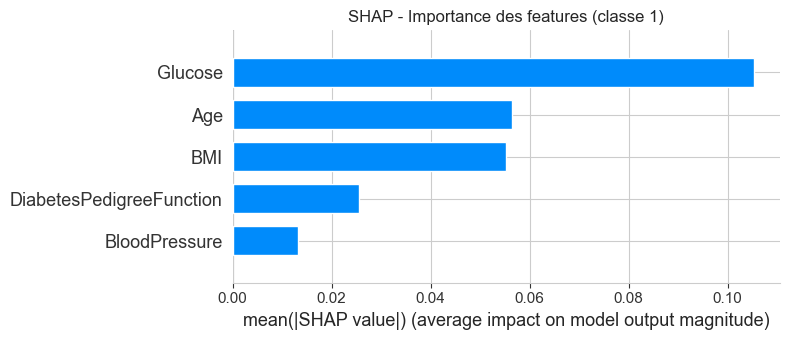

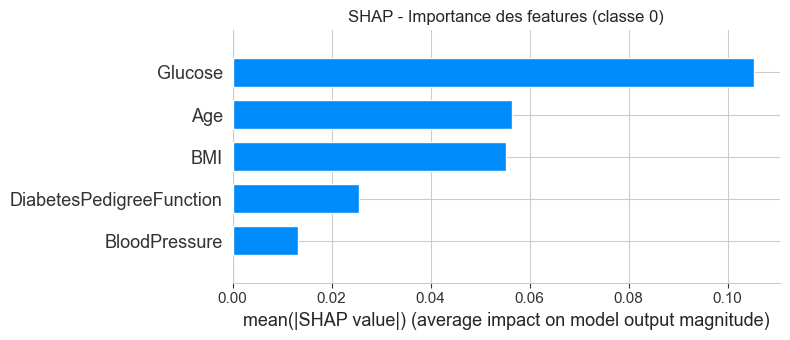

In [264]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

feature_names = list(X_test_1.columns)

# 1. Créer l'explainer
explainer = shap.Explainer(lambda x: model_ANN.predict(x, verbose=0), X_train_scaled)

# 2. Calculer les valeurs SHAP (pour la classe 1, sortie native du modèle)
shap_values = explainer(X_test_scaled, silent=True)

# --- Summary plot pour la CLASSE 1 ---
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type="bar",
    feature_names=feature_names,
    show=False
)
plt.title("SHAP - Importance des features (classe 1)")
plt.tight_layout()
plt.show()

# --- Summary plot pour la CLASSE 0 (juste le signe inversé) ---
shap_values_classe0 = shap.Explanation(
    values=-shap_values.values,          # signe inversé
    base_values=1 - shap_values.base_values,  # base_value inversée aussi
    data=shap_values.data,
    feature_names=feature_names
)

shap.summary_plot(
    shap_values_classe0,
    X_test_scaled,
    plot_type="bar",
    feature_names=feature_names,
    show=False
)
plt.title("SHAP - Importance des features (classe 0)")
plt.tight_layout()
plt.show()

Lime

Lime: Importance moyenne NÉGATIF La feature diminue la probabilité prédite de la classe demandée (elle pousse vers l'autre classe).

Exemple pour label=1 (diabétique) : Glucose <= 99   →  weight = -0.35

Signifie : avoir un glucose bas diminue la probabilité de "classe 1" — autrement dit, ça pousse vers la classe 0 (non diabétique).


Poids POSITIF : La feature augmente la probabilité prédite de la classe demandée.

Exemple pour label=1 (diabétique) : Glucose > 139   →  weight = +0.42

Signifie : avoir un glucose élevé augmente la probabilité que le modèle prédise "classe 1" (diabétique). Plus le poids est grand, plus l'effet est fort.

In [261]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

feature_names = list(X_test_1.columns)

# 1. Créer l'expliqueur LIME (données NON scalées)
explainer = LimeTabularExplainer(
    np.array(X_train_2),
    feature_names=feature_names ,
    class_names=['0', '1'],  # on explique les 2 classes
    mode='classification'
)

# 2. Fonction de prédiction qui retourne les PROBABILITÉS des 2 classes
def predict_fn(x):
    x_scaled = scaler.transform(x)
    y_pred_prob = model_ANN.predict(x_scaled, verbose=0)  
    y_pred_prob = y_pred_prob.reshape(-1, 1)               # security pour avoir shape (n, 1)
    return np.hstack([1 - y_pred_prob, y_pred_prob])       # shape (n, 2)

# 3. Générer les explications UNE SEULE FOIS pour toutes les instances
#    en demandant les 2 labels (0 et 1) en même temps -> pas besoin de relancer 2x
all_explanations = []

for i in range(X_test_1.shape[0]):
    exp_i = explainer.explain_instance(
        np.array(X_test_1)[i, :],
        predict_fn,
        num_features=X_test_1.shape[1],
        labels=[0, 1]  # on calcule les 2 classes 
    )
    all_explanations.append(exp_i)

#print(f"{len(all_explanations)} explications générées.")

# 4. Fonction d'affichage pour une classe donnée
def afficher_importance_lime(numero_classe, all_explanations):
    feature_importance_agg = {}
    for exp_i in all_explanations:
        for feature, weight in exp_i.as_list(label=numero_classe):
            feature_importance_agg.setdefault(feature, []).append(weight)  

    mean_importance = {
        feature: np.mean(weights)
        for feature, weights in feature_importance_agg.items()
    }

    # Trier par magnitude, mais garder le signe pour la couleur
    sorted_items = sorted(mean_importance.items(), key=lambda x: abs(x[1]), reverse=True)
    features, importances = zip(*sorted_items)
    colors = ['green' if v > 0 else 'red' for v in importances]

    plt.figure(figsize=(8, 5))
    plt.barh(features, importances, color=colors)
    plt.xlabel("Contribution moyenne")
    plt.title(f"Importance globale des features (LIME) - classe {numero_classe}")
    plt.axvline(0, color='gray', linestyle='--')
    plt.gca().invert_yaxis() 
    plt.tight_layout()
    plt.show()

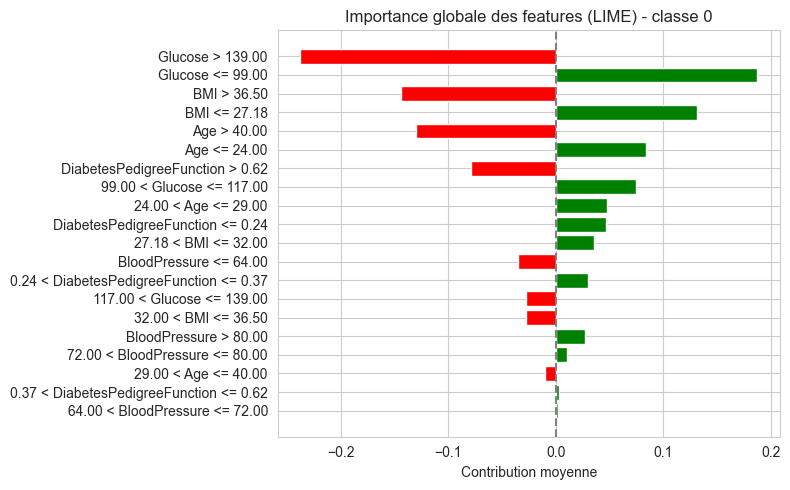

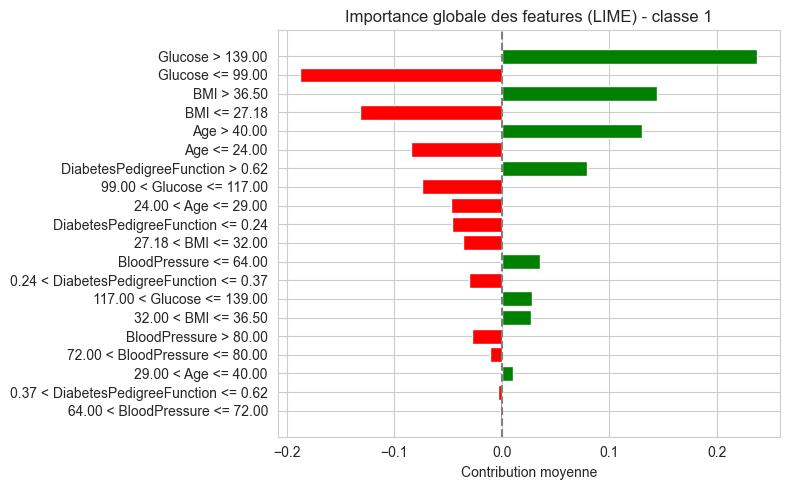

In [263]:
# 5. Afficher pour les 2 classes, à partir des MÊMES explications déjà calculées
afficher_importance_lime(0, all_explanations) 
afficher_importance_lime(1, all_explanations) # la classe 1 (diabétique) 